# 01 — Fetch and inspect the reference proteome

Uses `plm_benchmark.data_io` to download the *E. coli* K-12 reference proteome
FASTA from UniProt and parse it into a `{accession: sequence}` dict.

Kernel: **Python (plm-benchmark)** (the repo `.venv`). The download needs network
access, so run this notebook locally rather than in a sandbox with no egress.

In [1]:
import sys
from pathlib import Path

# notebooks/ lives one level below the repo root
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("repo root:", REPO_ROOT)

repo root: /Users/annaquaglieri/Projects/FunctionPrediction


In [2]:
import yaml

from plm_benchmark.data_io import fetch_uniprot_proteome, load_fasta

config = yaml.safe_load((REPO_ROOT / "configs" / "organism_ecoli_k12.yaml").read_text())
config

{'organism': 'Escherichia coli str. K-12 substr. MG1655',
 'uniprot_proteome_id': 'UP000000625',
 'taxon_id': 83333,
 'reviewed_only': True,
 'fasta_url': 'https://rest.uniprot.org/uniprotkb/stream?query=proteome:UP000000625+AND+reviewed:true&format=fasta&compressed=false',
 'notes': 'Small, extremely well-annotated bacterial reference proteome (~4,300 proteins). Chosen as the Phase 1 organism: fast to iterate on and directly relevant to bacterial metaproteomics.\n'}

## Download the FASTA

Skipped if the file is already on disk — delete it (or set `force = True`) to re-download.

In [3]:
proteome_id = config["uniprot_proteome_id"]
fasta_path = REPO_ROOT / "data" / "raw" / f"{proteome_id}.fasta"
force = False

if force or not fasta_path.exists():
    fasta_path = fetch_uniprot_proteome(
        proteome_id=proteome_id,
        out_path=fasta_path,
        reviewed_only=config["reviewed_only"],
    )
    print("downloaded ->", fasta_path)
else:
    print("already present ->", fasta_path)

print(f"{fasta_path.stat().st_size / 1e6:.1f} MB")

already present -> /Users/annaquaglieri/Projects/FunctionPrediction/data/raw/UP000000625.fasta
1.9 MB


## Parse the sequences

`load_fasta` keys on the header up to the first whitespace, i.e. the full
`sp|P0A7B8|...` style identifier.

In [4]:
sequences = load_fasta(fasta_path)

print(f"{len(sequences):,} sequences")
for header, seq in list(sequences.items())[:3]:
    print(f"\n{header}  (len {len(seq)})")
    print(seq[:80] + ("..." if len(seq) > 80 else ""))

4,403 sequences

sp|A5A616|MGTS_ECOLI  (len 31)
MLGNMNVFMAVLGIILFSGFLAAYFSHKWDD

sp|O32583|THIS_ECOLI  (len 66)
MQILFNDQAMQCAAGQTVHELLEQLDQRQAGAALAINQQIVPREQWAQHIVQDGDQILLFQVIAGG

sp|P00350|6PGD_ECOLI  (len 468)
MSKQQIGVVGMAVMGRNLALNIESRGYTVSIFNRSREKTEEVIAENPGKKLVPYYTVKEFVESLETPRRILLMVKAGAGT...


In [5]:
import pandas as pd

df = pd.DataFrame(
    {"header": list(sequences), "sequence": list(sequences.values())}
)
# UniProt FASTA headers look like db|accession|entry_name
header_parts = df["header"].str.split("|", n=2, expand=True)
df["accession"] = header_parts[1]
df["entry_name"] = header_parts[2]
df["length"] = df["sequence"].str.len()

display(df[["accession", "entry_name", "length"]].head())
df["length"].describe()

,accession,entry_name,length
0,A5A616,MGTS_ECOLI,31
1,O32583,THIS_ECOLI,66
2,P00350,6PGD_ECOLI,468
3,P00363,FRDA_ECOLI,602
4,P00370,DHE4_ECOLI,447


count    4403.000000
mean      307.617988
std       211.775119
min         8.000000
25%       158.000000
50%       271.000000
75%       404.500000
max      2339.000000
Name: length, dtype: float64

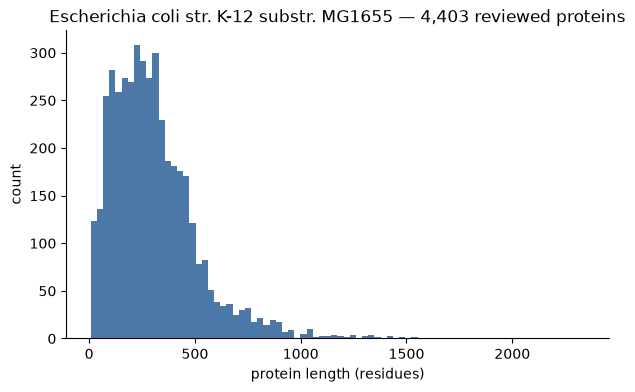

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["length"], bins=80, color="#4C78A8")
ax.set_xlabel("protein length (residues)")
ax.set_ylabel("count")
ax.set_title(f"{config['organism']} — {len(df):,} reviewed proteins")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Next

`sequences` is the input to `plm_benchmark.digest` (in-silico digestion) and
`plm_benchmark.fragments` (sliding-window / terminal truncation).